In [23]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

In [24]:
ckpt_files = glob.glob(f"./hww_pcres_regressor/logs/version_0/checkpoints/*")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Using checkpoint: ./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=373-val_loss=9.54.ckpt


In [25]:
dm = train.main(train=False) # Retrieve datamodule used in training
model = LightningWBoson.load_from_checkpoint(ckpt_path) # Load model from checkpoint
model.eval()

# Get the test dataloader
dm.setup(stage="test")
test_loader = dm.test_dataloader()

# Run inference
predictions = np.empty([0, dm.Y.shape[1]]) # Without including W0 and W1 mass
true_labels = np.empty([0, dm.Y.shape[1]])
train_features = np.empty([0, dm.X.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for batch in test_loader:
        inputs, targets = batch
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
    
        outputs = model(inputs)

        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...


Training objects shape: (2963488, 12)
Lepton in W rest frame shapes: (2963488, 4) (2963488, 4)
Target objects shape: (2963488, 10)
Loading model from checkpoint for evaluation... return datamodule


In [26]:
pred_lep_pos_px = predictions[..., 0]
pred_lep_pos_py = predictions[..., 1]
pred_lep_pos_pz = predictions[..., 2]
pred_lep_pos_energy = predictions[..., 3]
pred_lep_neg_px = predictions[..., 4]
pred_lep_neg_py = predictions[..., 5]
pred_lep_neg_pz = predictions[..., 6]
pred_lep_neg_energy = predictions[..., 7]
pred_w0_mass = predictions[..., 8]
pred_w1_mass = predictions[..., 9]

true_lep_pos_px = true_labels[..., 0]
true_lep_pos_py = true_labels[..., 1]
true_lep_pos_pz = true_labels[..., 2]
true_lep_pos_energy = true_labels[..., 3]
true_lep_neg_px = true_labels[..., 4]
true_lep_neg_py = true_labels[..., 5]
true_lep_neg_pz = true_labels[..., 6]
true_lep_neg_energy = true_labels[..., 7]
true_w0_mass = true_labels[..., 8]
true_w1_mass = true_labels[..., 9]

In [27]:
def rmse(pred, truth):
	return np.sqrt(np.mean((pred - truth) ** 2))

In [28]:
import mplhep as hep
hep.style.use("ATLAS")

def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 61), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 61), log=False, unit="GeV", color="black", vmax=1e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

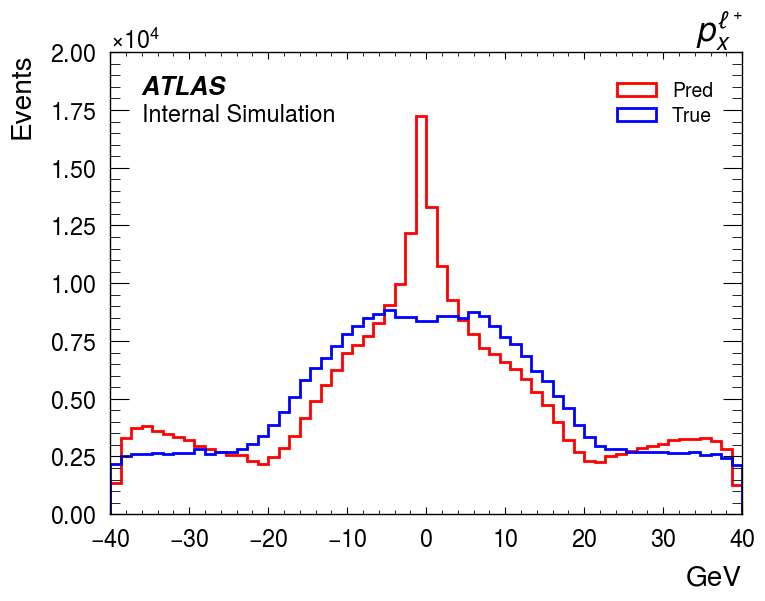

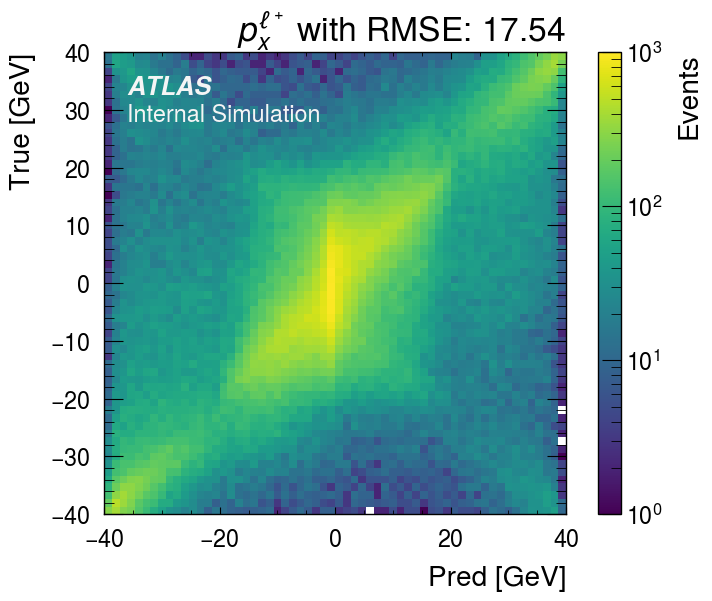

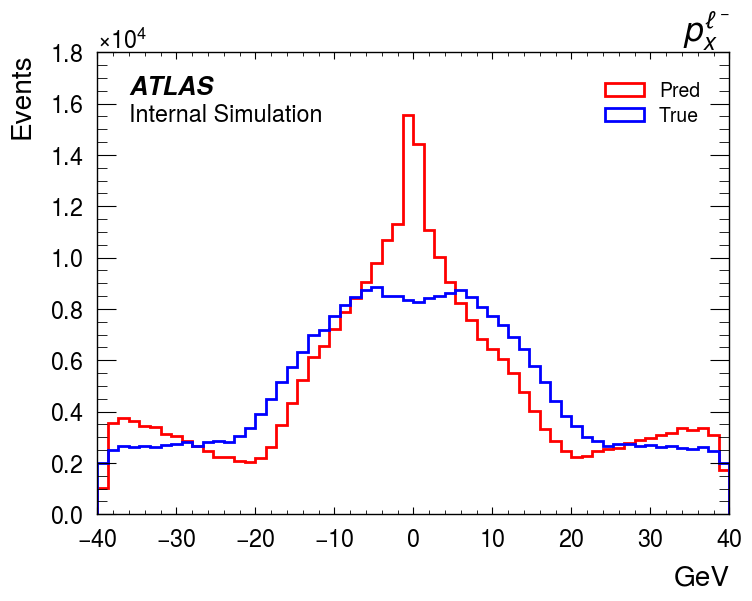

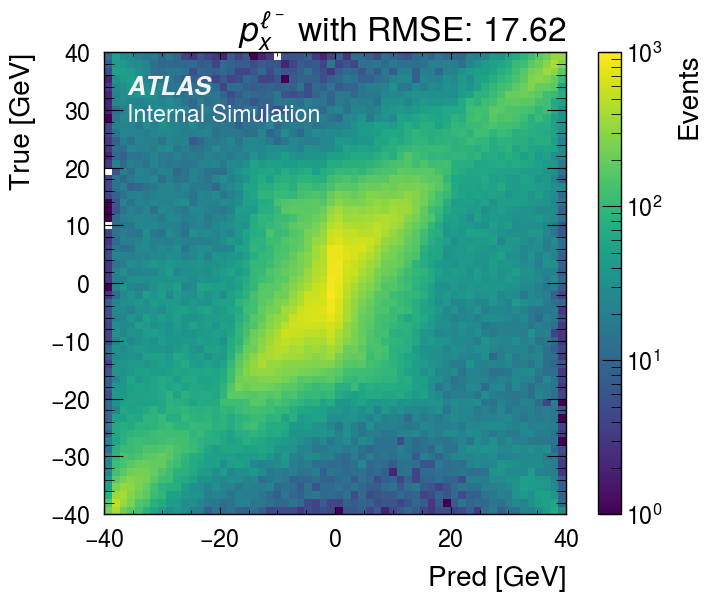

In [29]:
bins = np.linspace(-40, 40, 61)
plot_1d_hist(pred_lep_pos_px, true_lep_pos_px, bins_edges=bins, name=r"$p_x^{\ell^+}$", savepath="./figures/lep_pos/px.pdf")
plot_2d_hist(pred_lep_pos_px, true_lep_pos_px, name=r"$p_x^{\ell^+}$", bins_edges=bins, log=True, color="whitesmoke", savepath="./figures/lep_pos/px_2d.pdf")
plot_1d_hist(pred_lep_neg_px, true_lep_neg_px, bins_edges=bins, name=r"$p_x^{\ell^-}$", savepath="./figures/lep_neg/px.pdf")
plot_2d_hist(pred_lep_neg_px, true_lep_neg_px, name=r"$p_x^{\ell^-}$", bins_edges=bins, log=True, color="whitesmoke", savepath="./figures/lep_neg/px_2d.pdf")

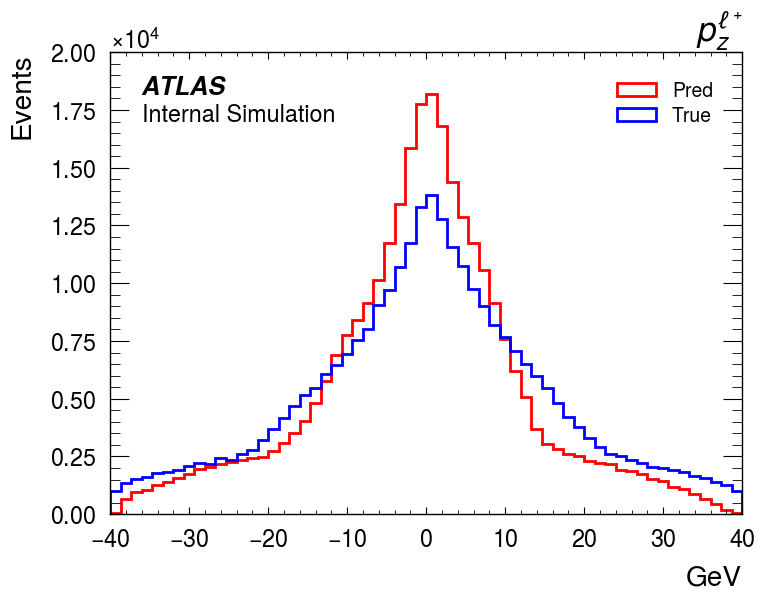

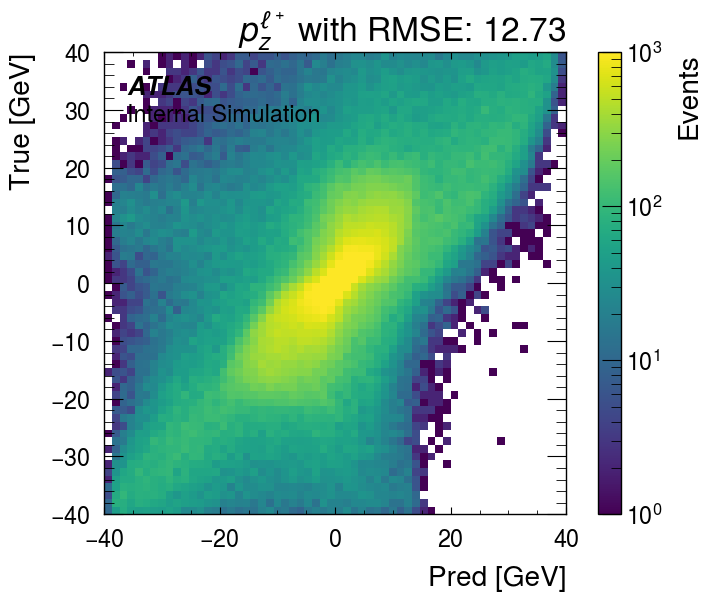

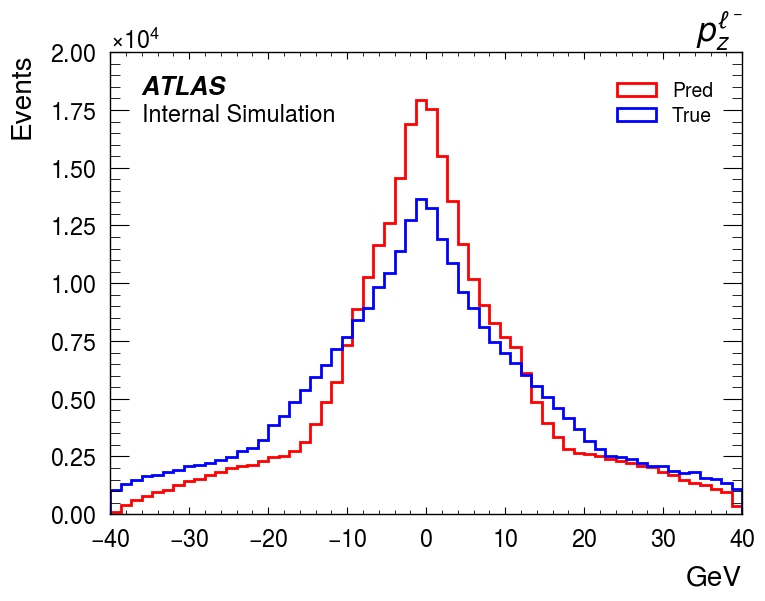

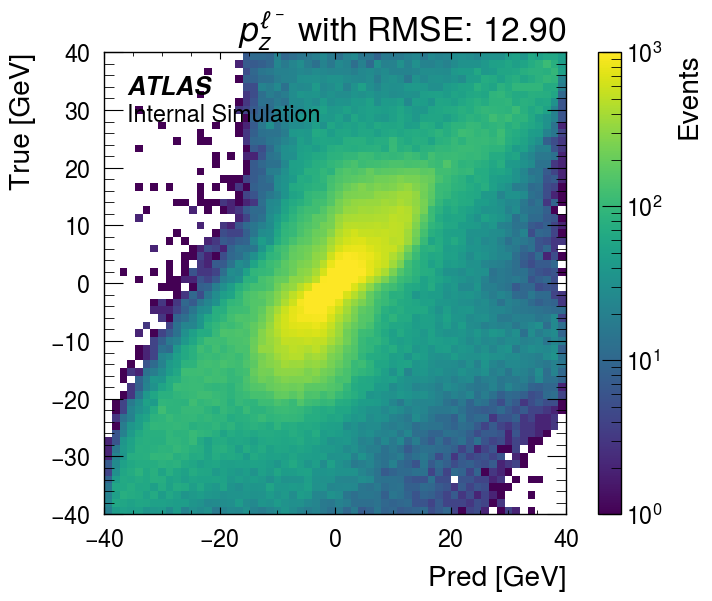

In [30]:
bins = np.linspace(-40, 40, 61)
plot_1d_hist(pred_lep_pos_pz, true_lep_pos_pz, bins_edges=bins, name=r"$p_z^{\ell^+}$", savepath="./figures/lep_pos/pz.pdf")
plot_2d_hist(pred_lep_pos_pz, true_lep_pos_pz, name=r"$p_z^{\ell^+}$", bins_edges=bins, log=True, color="black", savepath="./figures/lep_pos/pz_2d.pdf")
plot_1d_hist(pred_lep_neg_pz, true_lep_neg_pz, bins_edges=bins, name=r"$p_z^{\ell^-}$", savepath="./figures/lep_neg/pz.pdf")
plot_2d_hist(pred_lep_neg_pz, true_lep_neg_pz, name=r"$p_z^{\ell^-}$", bins_edges=bins, log=True, color="black", savepath="./figures/lep_neg/pz_2d.pdf")

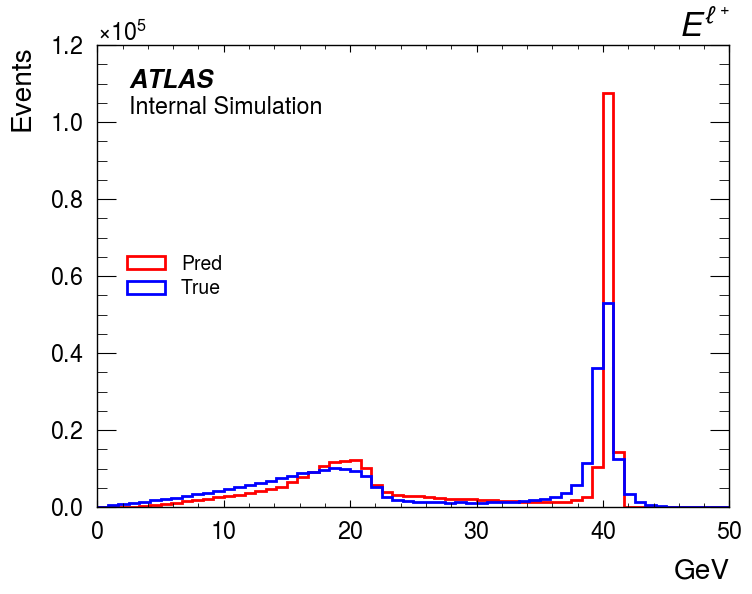

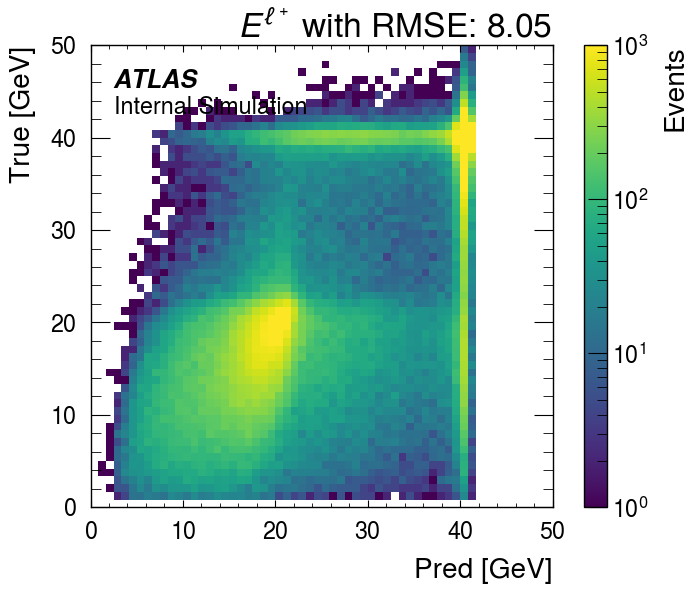

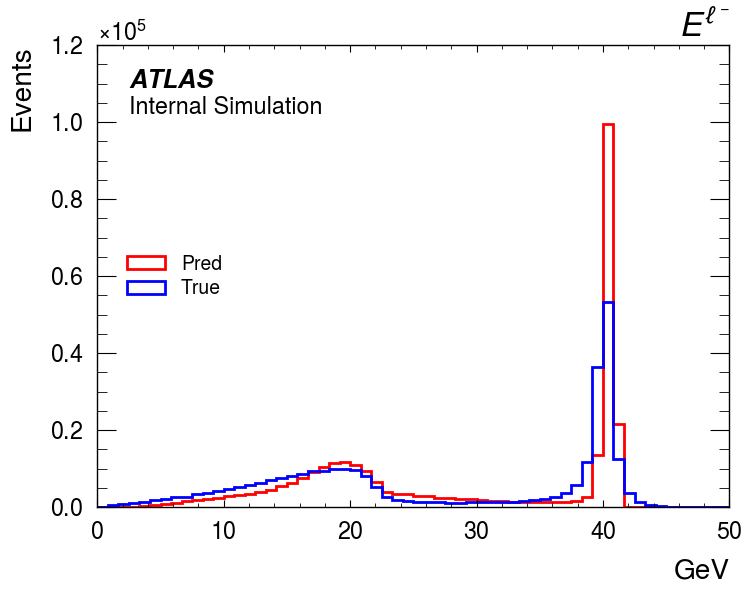

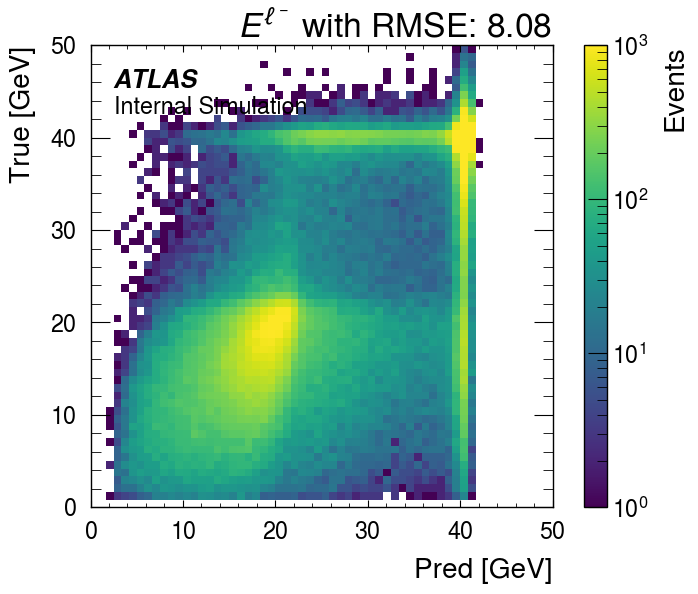

In [31]:
bins = np.linspace(0, 50, 61)
plot_1d_hist(pred_lep_pos_energy, true_lep_pos_energy, bins_edges=bins, name=r"$E^{\ell^+}$", savepath="./figures/lep_pos/energy.pdf")
plot_2d_hist(pred_lep_pos_energy, true_lep_pos_energy, name=r"$E^{\ell^+}$", bins_edges=bins, log=True, color="black", savepath="./figures/lep_pos/energy_2d.pdf")
plot_1d_hist(pred_lep_neg_energy, true_lep_neg_energy, bins_edges=bins, name=r"$E^{\ell^-}$", savepath="./figures/lep_neg/energy.pdf")
plot_2d_hist(pred_lep_neg_energy, true_lep_neg_energy, name=r"$E^{\ell^-}$", bins_edges=bins, log=True, color="black", savepath="./figures/lep_neg/energy_2d.pdf")

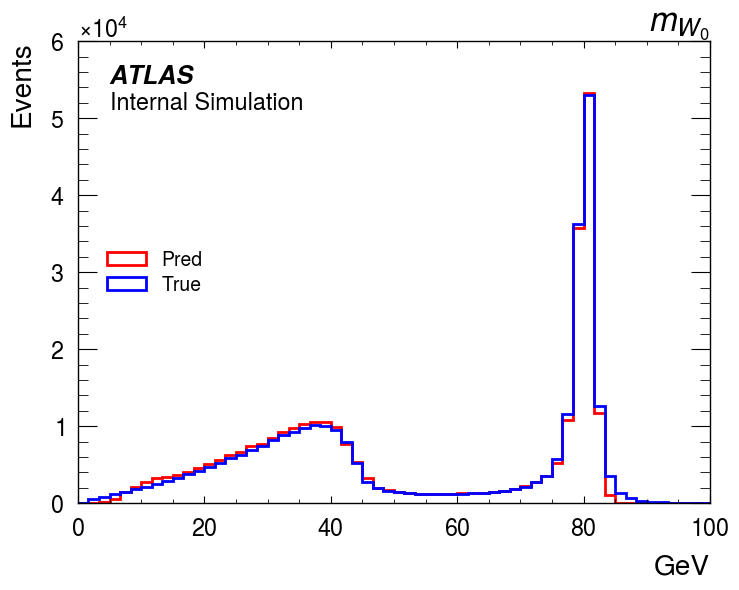

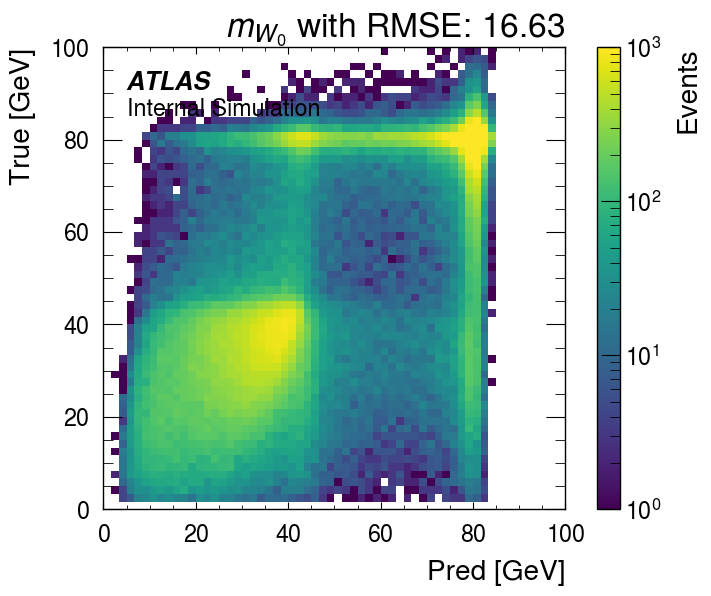

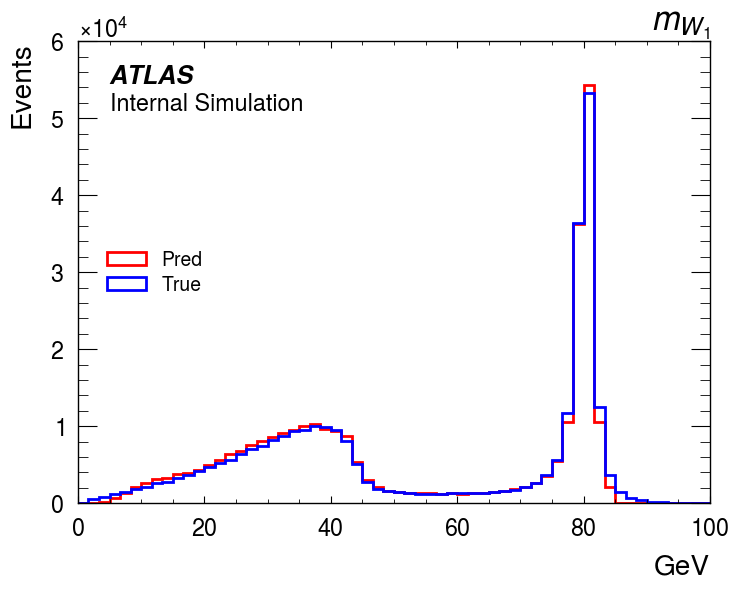

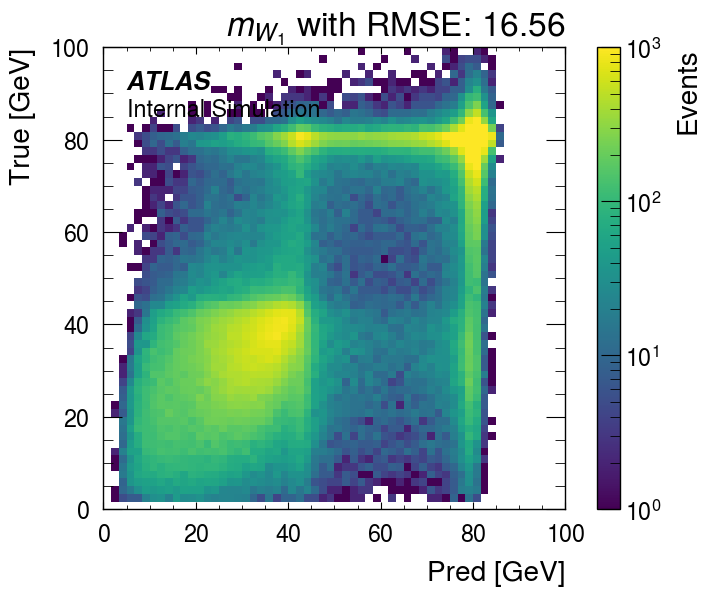

In [32]:
bins = np.linspace(0, 100, 61)
plot_1d_hist(pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"$m_{W_0}$", unit="GeV", savepath="./figures/w_pos/mass.pdf")
plot_2d_hist(pred_w0_mass, true_w0_mass, name=r"$m_{W_0}$", bins_edges=bins, log=True, unit="GeV", color="black", savepath="./figures/w_pos/mass_2d.pdf")
plot_1d_hist(pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"$m_{W_1}$", unit="GeV", savepath="./figures/w_neg/mass.pdf")
plot_2d_hist(pred_w1_mass, true_w1_mass, name=r"$m_{W_1}$", bins_edges=bins, log=True, unit="GeV", color="black", savepath="./figures/w_neg/mass_2d.pdf")

In [33]:
def pt(px, py):
    return np.sqrt(np.square(px) + np.square(py))


def eta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arcsinh(np.divide(pz, pt))

def theta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arctan2(pt, pz)

def phi(px, py):
    return np.arctan2(py, px)

In [34]:
pred_lep_pos_eta = eta(pred_lep_pos_px, pred_lep_pos_py, pred_lep_pos_pz)
true_lep_pos_eta = eta(true_lep_pos_px, true_lep_pos_py, true_lep_pos_pz)
pred_lep_neg_eta = eta(pred_lep_neg_px, pred_lep_neg_py, pred_lep_neg_pz)
true_lep_neg_eta = eta(true_lep_neg_px, true_lep_neg_py, true_lep_neg_pz)

pred_lep_pos_theta = theta(pred_lep_pos_px, pred_lep_pos_py, pred_lep_pos_pz)
true_lep_pos_theta = theta(true_lep_pos_px, true_lep_pos_py, true_lep_pos_pz)
pred_lep_neg_theta = theta(pred_lep_neg_px,	pred_lep_neg_py, pred_lep_neg_pz)
true_lep_neg_theta = theta(true_lep_neg_px, true_lep_neg_py, true_lep_neg_pz)

pred_lep_pos_phi = phi(pred_lep_pos_px, pred_lep_pos_py)
true_lep_pos_phi = phi(true_lep_pos_px, true_lep_pos_py)
pred_lep_neg_phi = phi(pred_lep_neg_px, pred_lep_neg_py)
true_lep_neg_phi = phi(true_lep_neg_px, true_lep_neg_py)

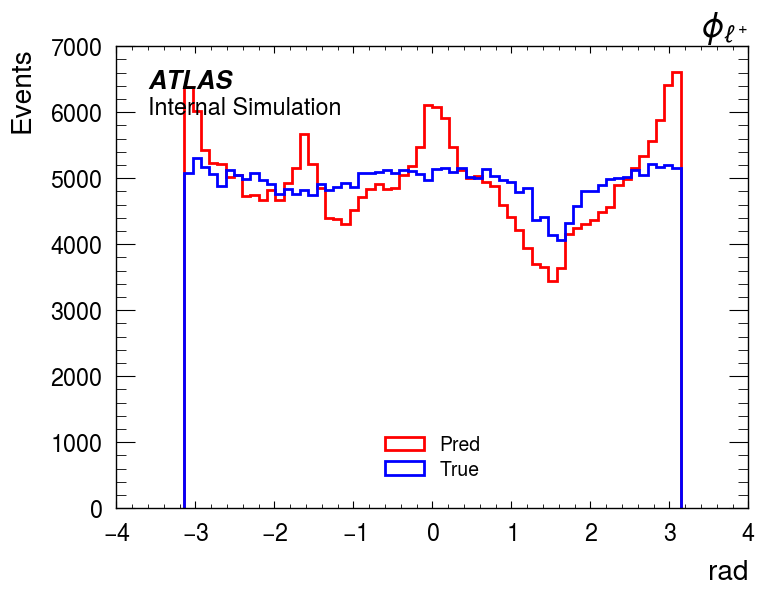

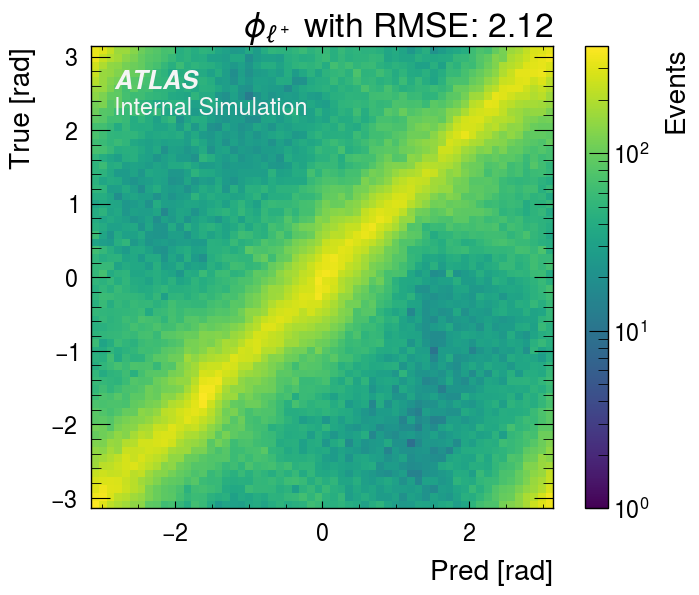

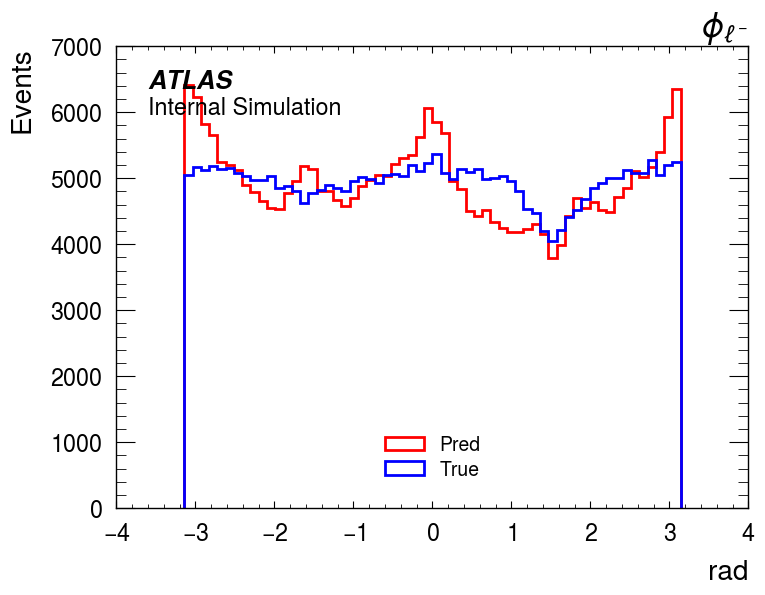

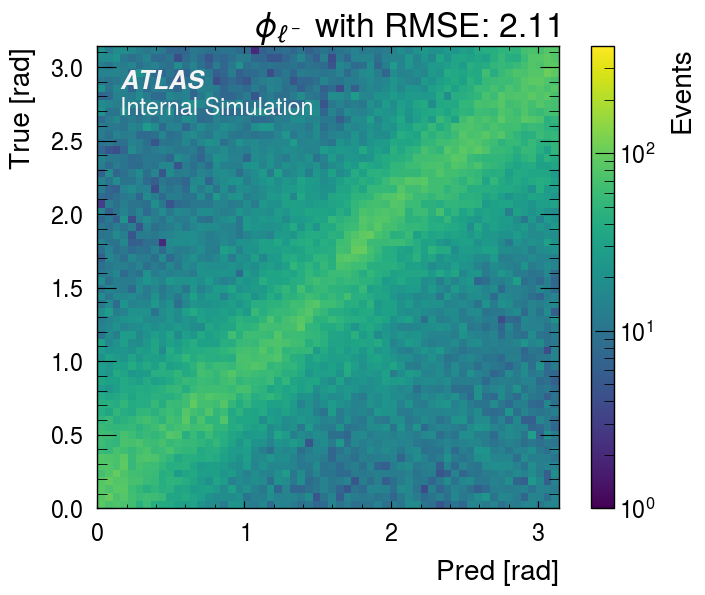

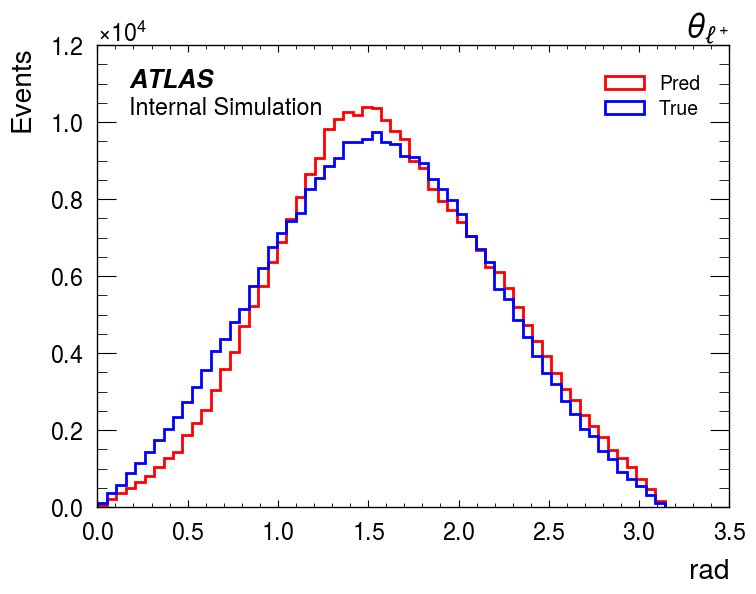

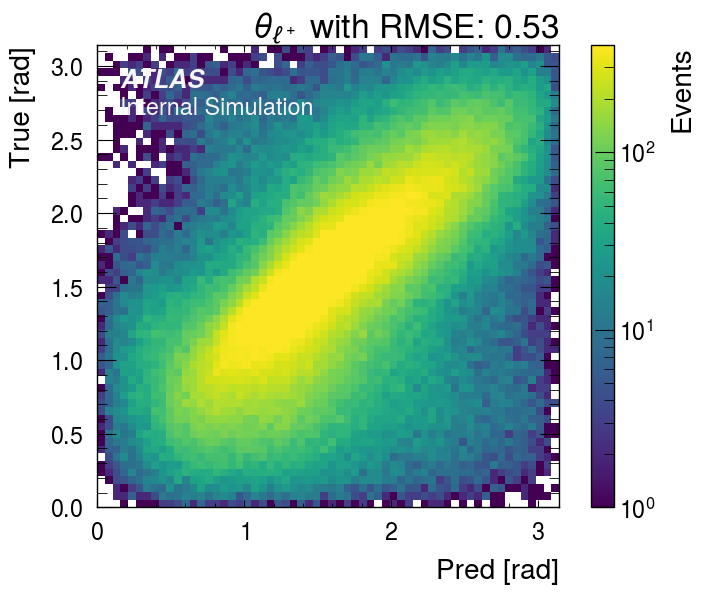

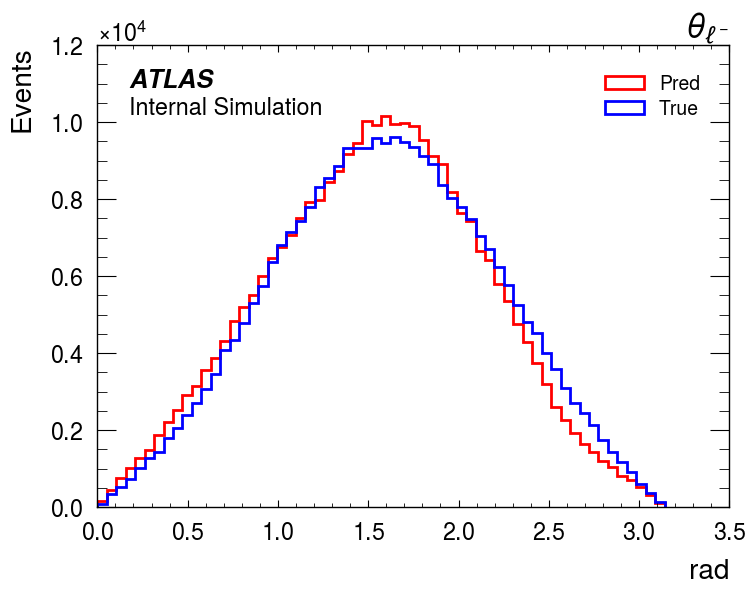

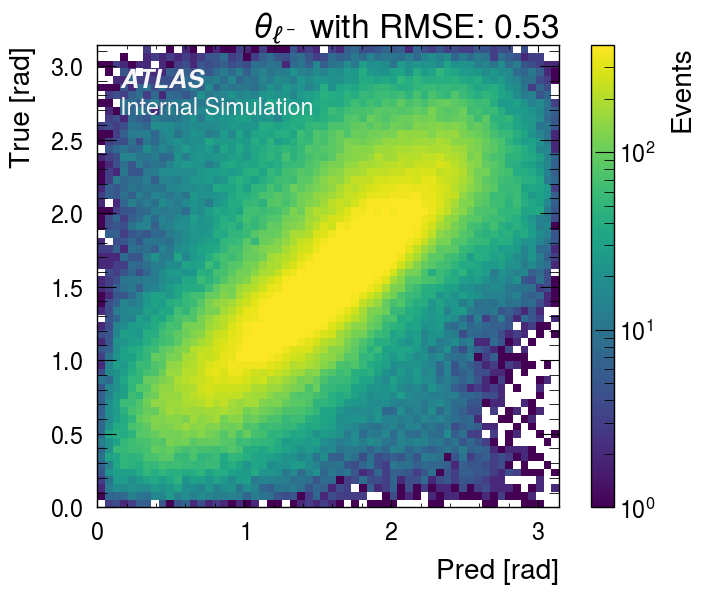

In [35]:
plot_1d_hist(pred_lep_pos_phi, true_lep_pos_phi, bins_edges=np.linspace(-np.pi, np.pi, 61), name=r"$\phi_{\ell^+}$", unit="rad", savepath="./figures/lep_pos/phi.pdf")
plot_2d_hist(pred_lep_pos_phi, true_lep_pos_phi, name=r"$\phi_{\ell^+}$", bins_edges=np.linspace(-np.pi, np.pi, 61), vmax=4e2, color="whitesmoke", log=True, unit="rad", savepath="./figures/lep_pos/phi_2d.pdf")
plot_1d_hist(pred_lep_neg_phi, true_lep_neg_phi, bins_edges=np.linspace(-np.pi, np.pi, 61), name=r"$\phi_{\ell^-}$", unit="rad", savepath="./figures/lep_neg/phi.pdf")
plot_2d_hist(pred_lep_neg_phi, true_lep_neg_phi, name=r"$\phi_{\ell^-}$", bins_edges=np.linspace(0, np.pi, 61), vmax=4e2, color="whitesmoke", log=True, unit="rad", savepath="./figures/lep_neg/phi_2d.pdf")
plot_1d_hist(pred_lep_pos_theta, true_lep_pos_theta, bins_edges=np.linspace(0, np.pi, 61), name=r"$\theta_{\ell^+}$", unit="rad", savepath="./figures/lep_pos/theta.pdf")
plot_2d_hist(pred_lep_pos_theta, true_lep_pos_theta, name=r"$\theta_{\ell^+}$", bins_edges=np.linspace(0, np.pi, 61), vmax=4e2, color="whitesmoke", log=True, unit="rad", savepath="./figures/lep_pos/theta_2d.pdf")
plot_1d_hist(pred_lep_neg_theta, true_lep_neg_theta, bins_edges=np.linspace(0, np.pi, 61), name=r"$\theta_{\ell^-}$", unit="rad", savepath="./figures/lep_neg/theta.pdf")
plot_2d_hist(pred_lep_neg_theta, true_lep_neg_theta, name=r"$\theta_{\ell^-}$", bins_edges=np.linspace(0, np.pi, 61), vmax=4e2, color="whitesmoke", log=True, unit="rad", savepath="./figures/lep_neg/theta_2d.pdf")

Found log directories: ['./hww_pcres_regressor/logs/version_0']


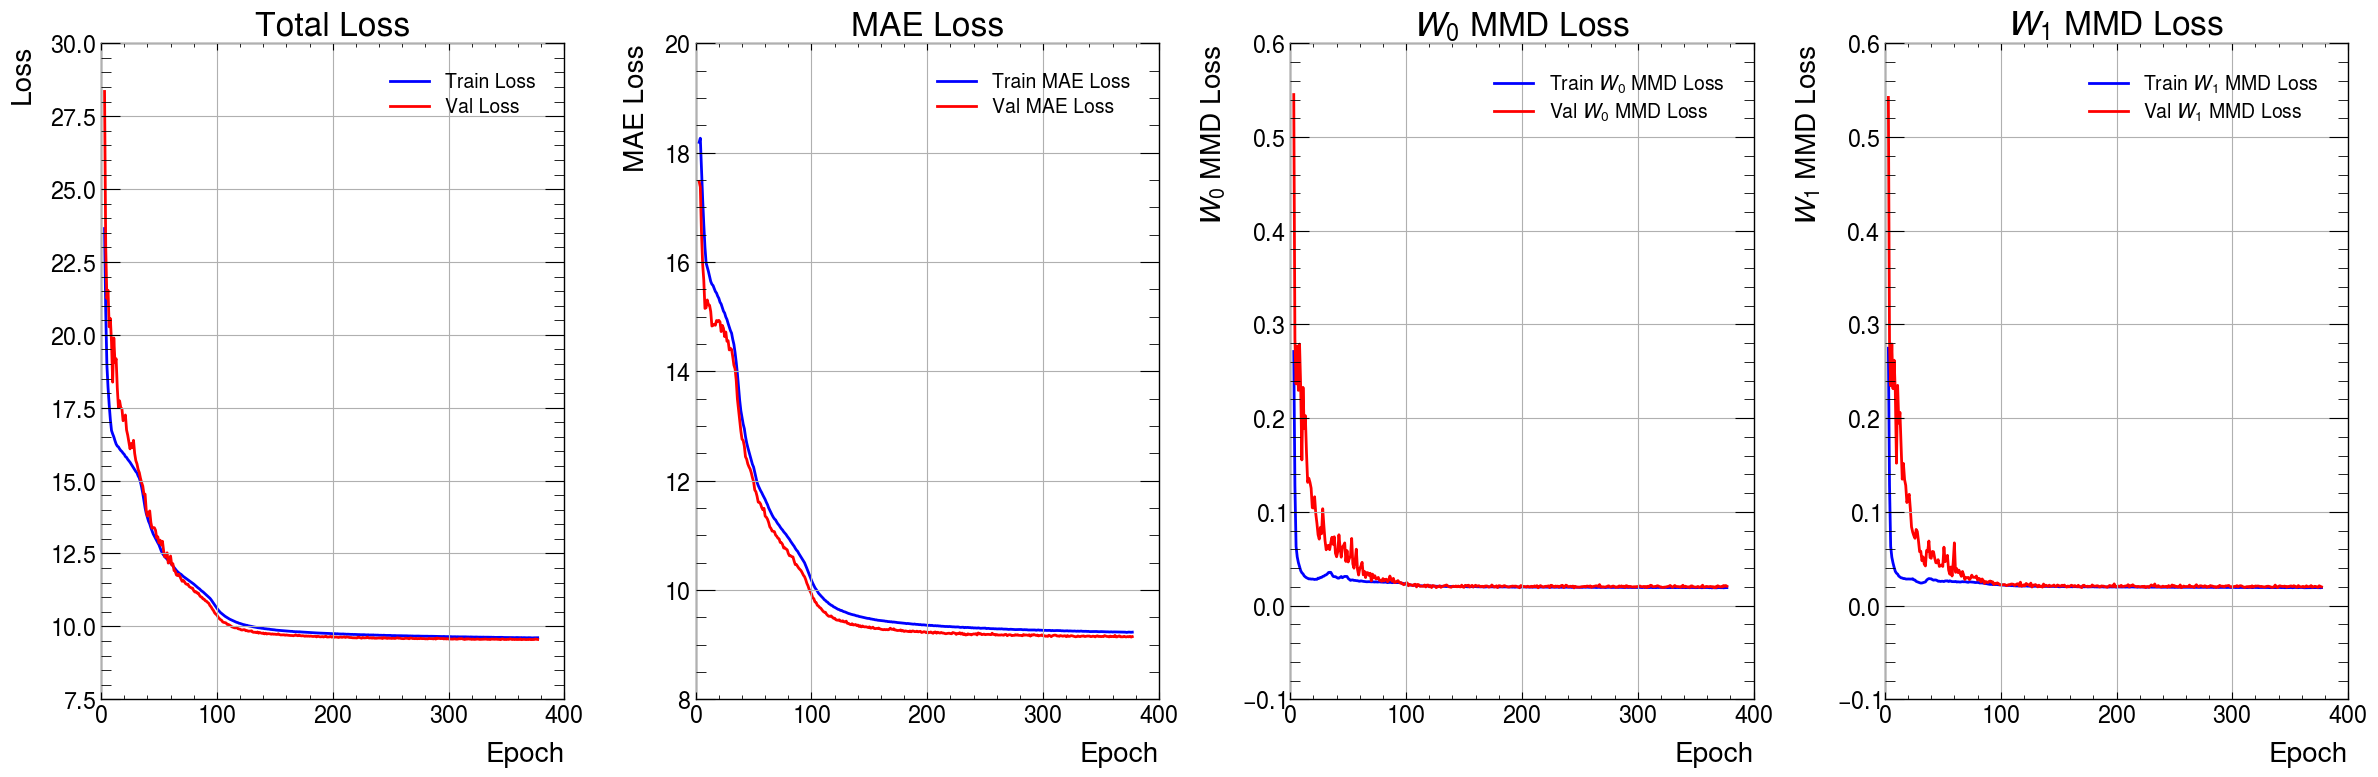


Final Training Losses (Epoch 377):
  Total Loss: 9.610102
  MAE Loss: 9.227523
  $W_0$ MMD Loss: 0.019136
  $W_1$ MMD Loss: 0.019120

Final Validation Losses:
  Total Loss: 9.550938
  MAE Loss: 9.145288
  $W_0$ MMD Loss: 0.020619
  $W_1$ MMD Loss: 0.019946


In [36]:
log_dirs = glob.glob("./hww_pcres_regressor/logs/*")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(1, 4, figsize=(24, 8))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("mae_loss", "val_mae_loss", "MAE Loss", "MAE Loss"),
                # ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                # ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                # ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                # ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W_0$ MMD Loss", "$W_0$ MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W_1$ MMD Loss", "$W_1$ MMD Loss"),
                # ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W_0$ MAE Loss", "$W_0$ MAE Loss"),
                # ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W_1$ MAE Loss", "$W_1$ MAE Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[3:]
            epochs_val = df_clean_val["epoch"].iloc[3:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[3:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[3:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"\nFinal Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("\nFinal Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")